### 1.Objective

The objective of this project is to analyze DataCo's supply chain operations to identify opportunities for improving sales, profitability, customer satisfaction, and logistics performance by doing Exploratory Data AnaLysis using Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Data Loading

In [2]:
data=pd.read_csv("DataCoSupplyChainDataset.csv",encoding="latin")
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
data.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


### 3. Data Understanding

In [4]:
data.shape

(180519, 53)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [6]:
data.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [7]:
data.describe(include='object')

,Type,Delivery Status,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Lname,Customer Password,Customer Segment,...,Order City,Order Country,order date (DateOrders),Order Region,Order State,Order Status,Product Image,Product Name,shipping date (DateOrders),Shipping Mode
count,180519,180519,180519,180519,180519,180519,180519,180511,180519,180519,...,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519
unique,4,4,50,563,2,1,782,1109,1,3,...,3597,164,65752,23,1089,9,118,118,63701,4
top,DEBIT,Late delivery,Cleats,Caguas,EE. UU.,XXXXXXXXX,Mary,Smith,XXXXXXXXX,Consumer,...,Santo Domingo,Estados Unidos,12/14/2016 12:29,Central America,Inglaterra,COMPLETE,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,1/5/2016 5:58,Standard Class
freq,69295,98977,24551,66770,111146,180519,65150,64104,180519,93504,...,2211,24840,5,28341,6722,59491,24515,24515,10,107752


In [8]:
data.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [9]:
data.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [10]:
missing_values=data.isnull().sum()
print(missing_values)

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [11]:
missing_values[missing_values>0].sort_values(ascending=False)

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

In [12]:
data.duplicated().sum()

0

In [13]:
data.nunique().sort_values()

Product Description                   0
Product Status                        1
Customer Password                     1
Customer Email                        1
Late_delivery_risk                    2
Customer Country                      2
Customer Segment                      3
Type                                  4
Shipping Mode                         4
Delivery Status                       4
Days for shipment (scheduled)         4
Order Item Quantity                   5
Market                                5
Days for shipping (real)              7
Order Status                          9
Department Id                        11
Department Name                      11
Order Item Discount Rate             18
Order Region                         23
Customer State                       46
Category Name                        50
Category Id                          51
Product Category Id                  51
Product Price                        75
Order Item Product Price             75


In [14]:
#Removing the column with 100% missing values
data=data.drop(columns=['Product Description'])

In [15]:
data['Order Zipcode'].isnull().sum()

155679

In [16]:
data['Order Zipcode'].notnull().sum()

24840

In [17]:
#Although Important for geographic analysis of sales it have almost 86% data missing so removed
data=data.drop(columns=['Order Zipcode'])

In [18]:
data[data['Customer Zipcode'].isnull()]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
35704,DEBIT,2,1,66.379997,189.660004,Late delivery,1,65,Consumer Electronics,CA,...,Auvernia-Ródano-Alpes,COMPLETE,1352,65,http://images.acmesports.sports/Industrial+con...,Industrial consumer electronics,252.880005,0,11/4/2017 18:31,First Class
46440,PAYMENT,4,4,10.910000,38.959999,Shipping on time,0,75,Video Games,CA,...,Capital Nacional,PENDING_PAYMENT,1362,75,http://images.acmesports.sports/Fighting+video...,Fighting video games,39.750000,0,12/14/2017 15:18,Standard Class
82511,DEBIT,4,4,59.990002,299.959992,Shipping on time,0,63,Children's Clothing,CA,...,Inglaterra,COMPLETE,1350,63,http://images.acmesports.sports/Children+heaters,Children's heaters,357.100006,0,10/30/2017 0:29,Standard Class


#### Handling Missing Values in Customer Zipcode

The `Customer Zipcode` column contained only 3 missing values (0.002% of the dataset).

Since ZIP codes cannot be reliably inferred and this feature is not critical to the planned business analysis, the missing values were retained instead of being imputed or removing the records.

### 4. Data Cleaning

Based on the data quality assessment, columns with no analytical value or extremely high missing percentages were removed. Date columns were converted to datetime format, and the dataset was validated before analysis.

In [19]:
data[data['Customer Lname'].isnull()]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
41422,DEBIT,5,4,165.360001,337.459992,Late delivery,1,63,Children's Clothing,Caguas,...,Java Central,COMPLETE,1350,63,http://images.acmesports.sports/Children+heaters,Children's heaters,357.100006,0,12/26/2017 19:40,Standard Class
50447,DEBIT,2,4,213.690002,436.100006,Advance shipping,0,66,Crafts,Palatine,...,Estocolmo,COMPLETE,1353,66,http://images.acmesports.sports/Porcelain+crafts,Porcelain crafts,461.480011,0,11/9/2017 14:50,Standard Class
86260,TRANSFER,5,4,152.440002,419.950012,Late delivery,1,66,Crafts,Los Angeles,...,Guangdong,PENDING,1353,66,http://images.acmesports.sports/Porcelain+crafts,Porcelain crafts,461.480011,0,1/1/2018 19:19,Standard Class
92621,TRANSFER,2,1,-4.860000,194.240005,Late delivery,1,76,Women's Clothing,Caguas,...,Capital Nacional,PENDING,1363,76,http://images.acmesports.sports/Summer+dresses,Summer dresses,215.820007,0,12/15/2017 7:25,First Class
97530,DEBIT,4,2,82.540001,242.759995,Late delivery,1,65,Consumer Electronics,San Antonio,...,Lombardía,ON_HOLD,1352,65,http://images.acmesports.sports/Industrial+con...,Industrial consumer electronics,252.880005,0,11/4/2017 20:37,Second Class
120404,TRANSFER,3,4,157.830002,415.329987,Advance shipping,0,66,Crafts,Fayetteville,...,Renania del Norte-Westfalia,PENDING,1353,66,http://images.acmesports.sports/Porcelain+crafts,Porcelain crafts,461.480011,0,11/10/2017 1:10,Standard Class
166129,PAYMENT,2,2,-59.279999,296.390015,Shipping on time,0,63,Children's Clothing,Honolulu,...,Java Oriental,PENDING_PAYMENT,1350,63,http://images.acmesports.sports/Children+heaters,Children's heaters,357.100006,0,12/23/2017 16:52,Second Class
167119,PAYMENT,2,4,15.050000,200.710007,Advance shipping,0,76,Women's Clothing,Reseda,...,Uttar Pradesh,PENDING_PAYMENT,1363,76,http://images.acmesports.sports/Summer+dresses,Summer dresses,215.820007,0,1/29/2018 8:14,Standard Class


In [20]:
columns_to_drop = [
    'Customer Fname',
    'Customer Lname',
    'Customer Email',
    'Customer Password']

data = data.drop(columns=columns_to_drop)

In [21]:
data.shape

(180519, 47)

In [22]:
data[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

order date (DateOrders)       object
shipping date (DateOrders)    object
dtype: object

In [23]:
data['order date (DateOrders)'] = pd.to_datetime(data['order date (DateOrders)'])

data['shipping date (DateOrders)'] = pd.to_datetime(data['shipping date (DateOrders)'])

In [24]:
data[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object

### 5. Data validation

In [25]:
data['Sales'].describe()
(data['Sales'] < 0).sum()

0

#### Observation

Sales values are valid.
No negative sales were found.
The column is suitable for revenue analysis.

In [26]:
data['Order Item Quantity'].describe()

(data['Order Item Quantity'] <= 0).sum()

0

In [27]:
data['Order Profit Per Order'].describe()

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Order Profit Per Order, dtype: float64

In [28]:
data['Days for shipping (real)'].describe()

(data['Days for shipping (real)'] < 0).sum()

0

In [29]:
data['Days for shipment (scheduled)'].describe()

(data['Days for shipment (scheduled)'] < 0).sum()

0

In [30]:
(data['shipping date (DateOrders)'] < data['order date (DateOrders)']).sum()

0

In [31]:
data.to_csv("DataCo_Cleaned.csv", index=False)

### 6. Business Intelligence & Exploratory Analysis
The goal of this section is to identify trends, patterns, and operational inefficiencies in DataCo's supply chain that can support strategic business decisions.

#### 6.1 Executive Business Overview

##### Business Objective

This section provides a high-level overview of DataCo's business performance by summarizing the most important KPIs. These metrics help management quickly assess revenue, profitability, customer base, and operational scale before performing detailed analysis.

In [32]:
#executive KPIs
total_sales=data['Sales'].sum()
total_profit=data['Order Profit Per Order'].sum()
total_orders = data['Order Id'].nunique()
total_customers = data['Customer Id'].nunique()
avg_order_value = data['Sales'].mean()
avg_profit = data['Order Profit Per Order'].mean()

In [33]:
# Drop redundant 'Benefit per order' column
data.drop('Benefit per order', axis=1, inplace=True, errors='ignore')

In [34]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Average Profit per Order"
    ],
    "Value": [
         f"${total_sales:,.2f}",
        f"${total_profit:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"${avg_order_value:,.2f}",
        f"${avg_profit:,.2f}"
    ]
})

kpi_summary


,Metric,Value
0,Total Sales,"$36,784,735.01"
1,Total Profit,"$3,966,902.97"
2,Total Orders,"65,752"
3,Total Customers,"20,652"
4,Average Order Value,$203.77
5,Average Profit per Order,$21.97


#### Key Insights

- DataCo generated **over \$36.78 million** in sales across **65,752 unique orders**.
- The company served **20,652 unique customers**, indicating a broad customer base.
- The average order value was **approximately \$203.77**, while the average profit per order was **around \$21.97**.
- These KPIs establish the baseline for deeper analysis of sales performance, customer behavior, product profitability, and supply chain efficiency.

In [35]:
# Time Features

data['Order Year'] = data['order date (DateOrders)'].dt.year
data['Order Month'] = data['order date (DateOrders)'].dt.month_name()
data['Order Month No'] = data['order date (DateOrders)'].dt.month
data['Order Quarter'] = data['order date (DateOrders)'].dt.quarter
monthly_sales = (
    data.groupby(['Order Year', 'Order Month No', 'Order Month'])['Sales']
        .sum()
        .reset_index()
)

monthly_sales.head()


,Order Year,Order Month No,Order Month,Sales
0,2015,1,January,1.051590e+06
1,2015,2,February,9.270099e+05
2,2015,3,March,1.051254e+06
3,2015,4,April,1.014463e+06
4,2015,5,May,1.050478e+06


In [36]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']
sales_matrix = (
    data.groupby(['Order Year', 'Order Month'])['Sales']
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=month_order))
sales_matrix

Order Month,January,February,March,April,May,June,July,August,September,October,November,December
Order Year,,,,,,,,,,,,
2015,1.051590e+06,927009.898168,1.051254e+06,1.014463e+06,1.050478e+06,1.024006e+06,1.038081e+06,1.029495e+06,1.018339e+06,1.049154e+06,1.029120e+06,1.057841e+06
2016,1.046308e+06,968542.849025,1.025853e+06,1.001212e+06,1.029400e+06,1.003060e+06,1.045716e+06,1.048200e+06,1.002397e+06,1.048131e+06,1.047590e+06,1.037408e+06
2017,1.029698e+06,992534.898790,1.048005e+06,1.038322e+06,1.105485e+06,1.032086e+06,1.104373e+06,1.109337e+06,1.143775e+06,1.073994e+06,6.269144e+05,5.039108e+05
2018,3.316501e+05,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [37]:
complete_data = data[data['Order Year'].isin([2015, 2016])]

In [38]:
monthly_sales = (
    complete_data
    .groupby(['Order Year', 'Order Month No', 'Order Month'])['Sales']
    .sum()
    .reset_index())
monthly_avg = (
    monthly_sales
    .groupby(['Order Month No', 'Order Month'])['Sales']
    .mean()
    .reset_index()
    .sort_values('Order Month No'))

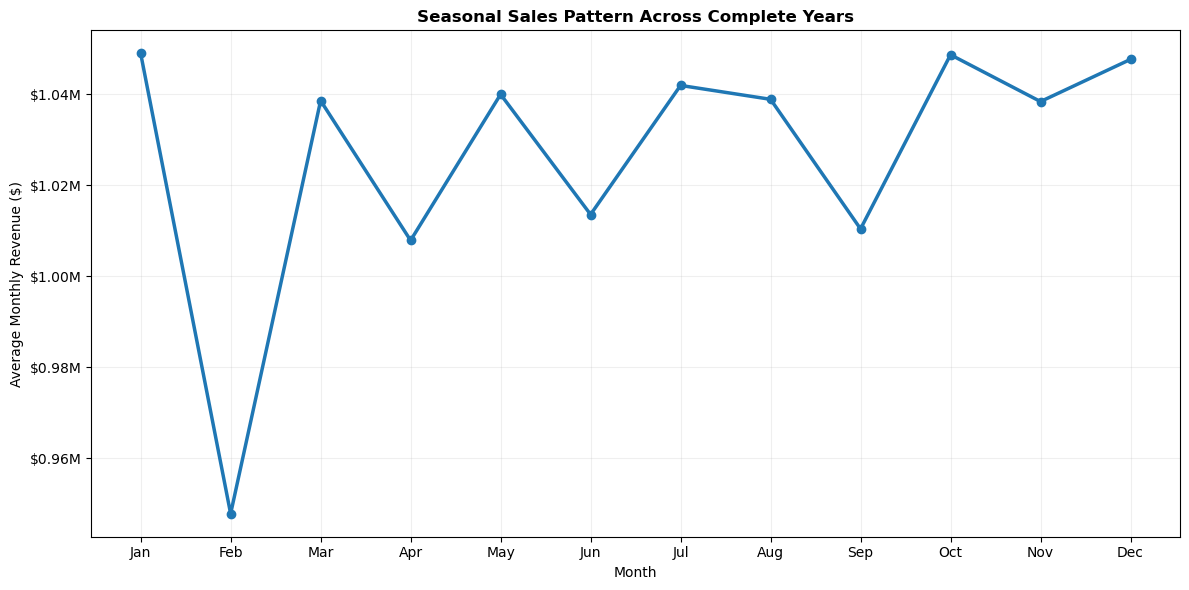

In [39]:
from matplotlib.ticker import FuncFormatter

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12,6))
plt.plot(months, monthly_avg['Sales'], marker='o', linewidth=2.5)

plt.title('Seasonal Sales Pattern Across Complete Years', weight='bold')
plt.xlabel('Month')
plt.ylabel('Average Monthly Revenue ($)')
plt.grid(alpha=0.2)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1e6:.2f}M')
)

plt.tight_layout()
plt.show()

#### Key Insight from the chart

February records the lowest average monthly revenue, while October and January show comparatively stronger sales. Overall, monthly revenue remains relatively stable, indicating limited seasonality.

#### 6.2 Market Performance Analysis

##### Business Question

Which geographical markets contribute the highest revenue?

-Understanding market-wise performance helps identify high-performing business regions and supports strategic expansion decisions.

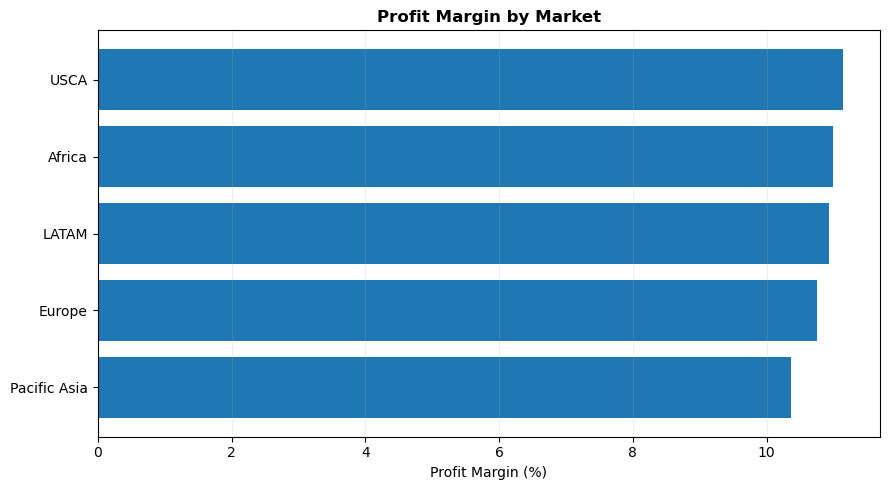

In [40]:
market_summary = (
    data.groupby('Market')
    .agg(
        Total_Sales=('Sales','sum'),
        Total_Profit=('Order Profit Per Order','sum')
    )
)

market_summary['Profit Margin (%)'] = (
    market_summary['Total_Profit'] /
    market_summary['Total_Sales'] * 100
)

market_summary = market_summary.sort_values('Profit Margin (%)')
plt.figure(figsize=(9,5))

plt.barh(
    market_summary.index,
    market_summary['Profit Margin (%)']
)

plt.title('Profit Margin by Market', weight='bold')
plt.xlabel('Profit Margin (%)')
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

#### Key Insight:
Profit margins are relatively consistent across markets, with only moderate variation. This suggests no single market is significantly underperforming, though higher-margin markets could be prioritized for growth.

#### 6.3 Category Performance

##### Business Question

Which product categories generate strong sales but weak profitability?

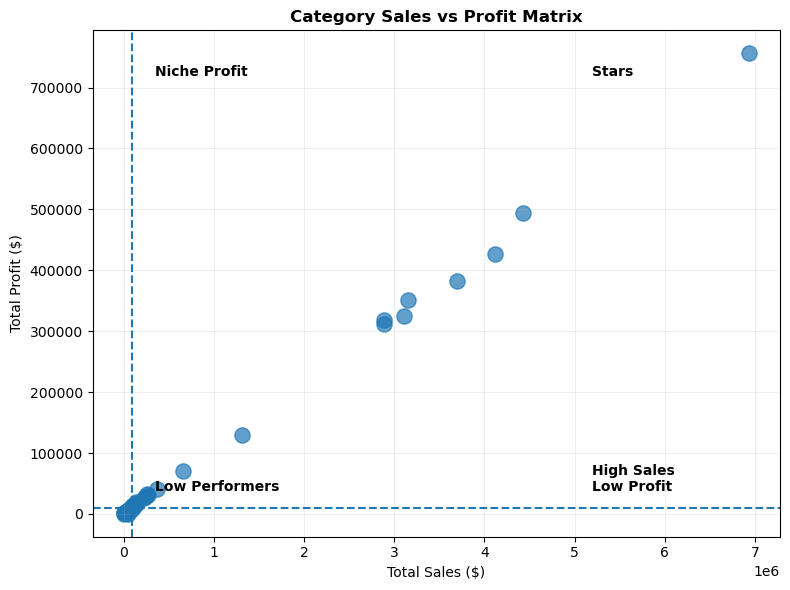

In [41]:
category_summary = (
    data.groupby('Category Name')
    .agg(
        Sales=('Sales','sum'),
        Profit=('Order Profit Per Order','sum')
    )
)
plt.figure(figsize=(8,6))

plt.scatter(
    category_summary['Sales'],
    category_summary['Profit'],
    s=120,
    alpha=0.7
)

# Median lines create four business quadrants
plt.axvline(category_summary['Sales'].median(),
            linestyle='--')

plt.axhline(category_summary['Profit'].median(),
            linestyle='--')

plt.title('Category Sales vs Profit Matrix', weight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Total Profit ($)')
plt.grid(alpha=0.2)
x_max = category_summary['Sales'].max()
y_max = category_summary['Profit'].max()

plt.text(x_max*0.75, y_max*0.95, 'Stars', weight='bold')
plt.text(x_max*0.05, y_max*0.95, 'Niche Profit', weight='bold')
plt.text(x_max*0.75, y_max*0.05, 'High Sales\nLow Profit', weight='bold')
plt.text(x_max*0.05, y_max*0.05, 'Low Performers', weight='bold')
plt.tight_layout()
plt.show()


#### Key Insight:
Categories differ significantly in their ability to convert sales into profit. High-sales but low-profit categories should be reviewed for pricing, discounting, or cost issues, while high-sales and high-profit categories should be prioritized.

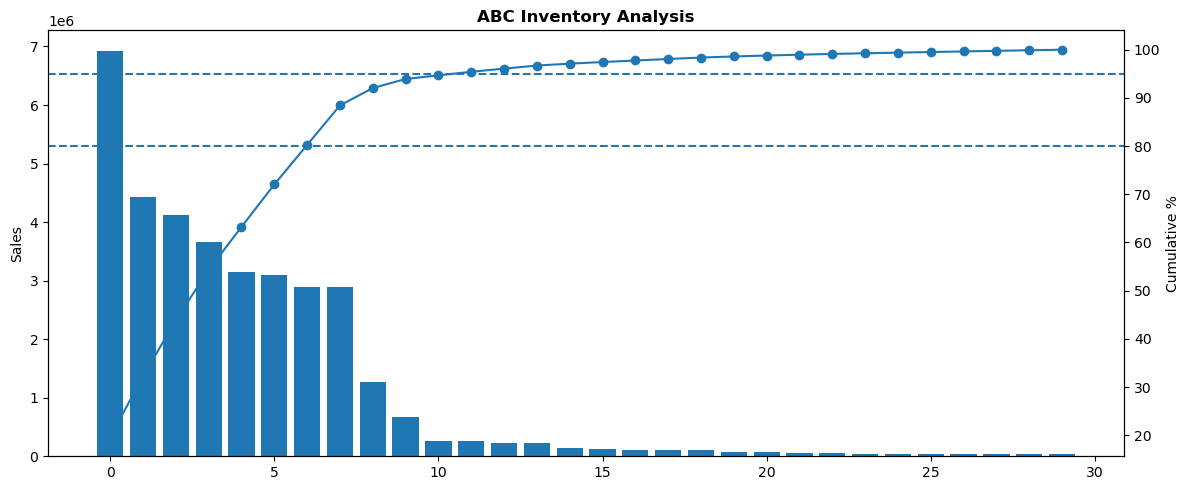

In [42]:
abc = (
    data.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .reset_index()
)

abc['Cum %'] = abc['Sales'].cumsum()/abc['Sales'].sum()*100
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.bar(range(len(abc)), abc['Sales'])

ax2 = ax1.twinx()

ax2.plot(
    range(len(abc)),
    abc['Cum %'],
    marker='o'
)

ax2.axhline(80, linestyle='--')
ax2.axhline(95, linestyle='--')

ax1.set_title('ABC Inventory Analysis', weight='bold')

ax1.set_ylabel('Sales')
ax2.set_ylabel('Cumulative %')

plt.tight_layout()
plt.show()

#### Key Insight:
A relatively small group of top products contributes a large share of sales, highlighting the importance of prioritizing these products for inventory availability and demand planning.

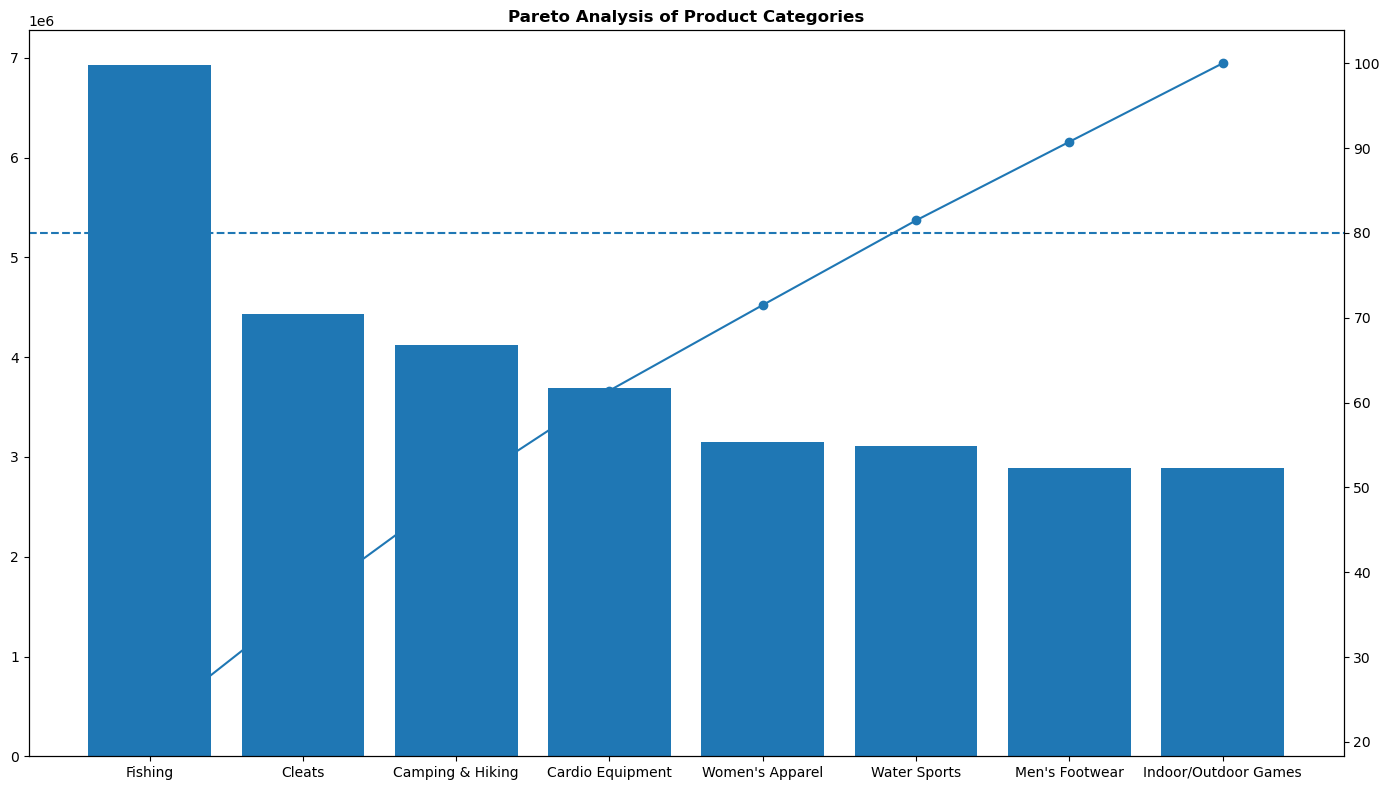

In [43]:
pareto = (
    data.groupby('Category Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)

pareto['Cum %'] = (
    pareto['Sales'].cumsum() /
    pareto['Sales'].sum() * 100
)
fig, ax1 = plt.subplots(figsize=(14,8))

ax1.bar(
    pareto['Category Name'],
    pareto['Sales']
)

ax2 = ax1.twinx()

ax2.plot(
    pareto['Category Name'],
    pareto['Cum %'],
    marker='o'
)

ax2.axhline(80, linestyle='--')

plt.xticks(rotation=90)

ax1.set_title('Pareto Analysis of Product Categories', weight='bold')

plt.tight_layout()
plt.show()

#### Key Insight:
Sales are concentrated among a limited number of product categories, indicating that a small portion of the portfolio drives most business revenue and deserves greater management focus.

In [44]:
data['Shipping Delay'] = data['Days for shipping (real)'] - data['Days for shipment (scheduled)']

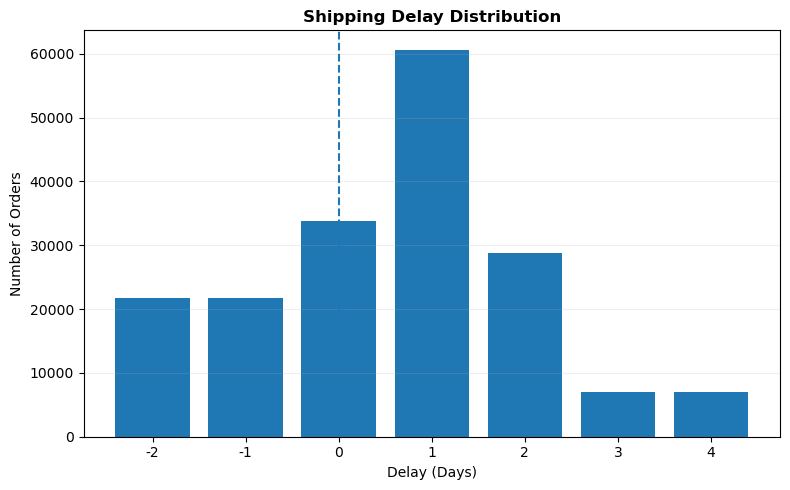

In [45]:
shipping_delay = (
    data['Shipping Delay']
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(8,5))

plt.bar(
    shipping_delay.index.astype(str),
    shipping_delay.values
)

plt.axvline(
    x=2,
    linestyle='--'
)

plt.title('Shipping Delay Distribution', weight='bold')

plt.xlabel('Delay (Days)')
plt.ylabel('Number of Orders')

plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

#### Key Insight:
Most orders are concentrated around lower shipping delays, but delayed orders still exist. Reducing these exceptions could improve delivery reliability and customer satisfaction.

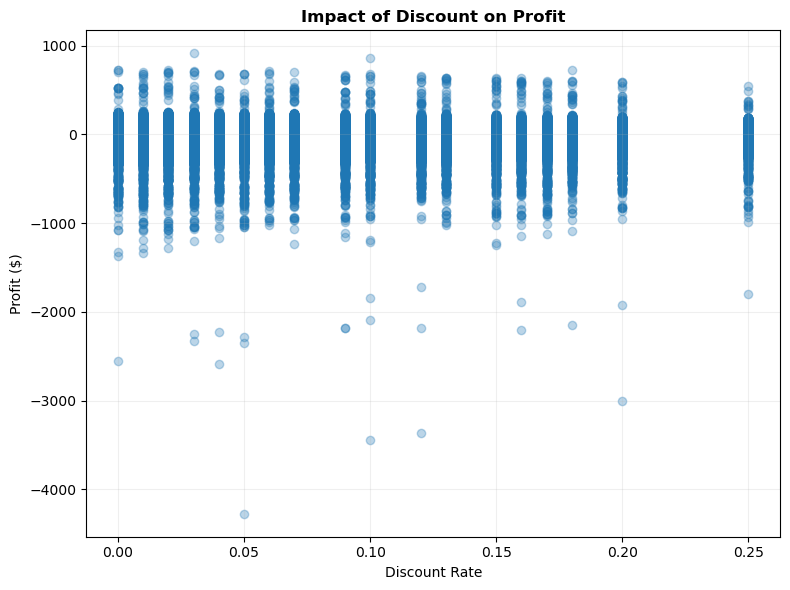

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(
    data['Order Item Discount Rate'],
    data['Order Profit Per Order'],
    alpha=0.3
)

plt.title('Impact of Discount on Profit', weight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [47]:
data['discount_bin'] = pd.cut(data['Order Item Discount Rate'], bins=[-0.01,0.05,0.10,0.15,0.20,0.25,1.0])
data.groupby('discount_bin', observed=True)['Order Profit Per Order'].mean().round(2)

discount_bin
(-0.01, 0.05]    23.94
(0.05, 0.1]      23.51
(0.1, 0.15]      21.47
(0.15, 0.2]      20.14
(0.2, 0.25]      18.41
Name: Order Profit Per Order, dtype: float64

#### Key Insights from the Decicon Analysis chart
"Discount analysis showed average profit per order declining steadily as discount rate increased — from approx **\$23.94 per order**  at 0–5\% discount to ~$18.41 per order at 20–25% discount, a ~23% reduction — indicating discounting directly erodes per-order profitability even though the frequency of loss-making orders remains roughly stable across discount bands."

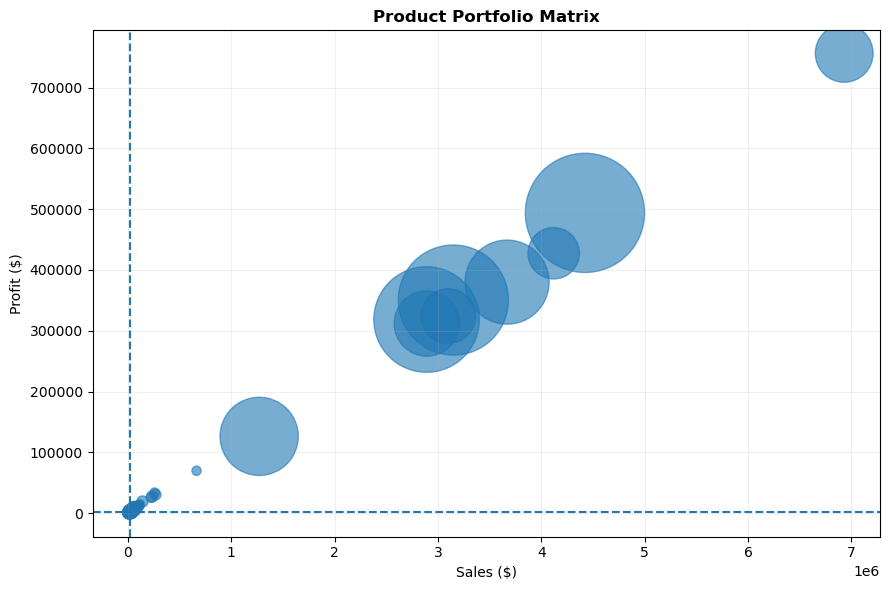

In [48]:
product_summary = (
    data.groupby('Product Name')
    .agg(
        Sales=('Sales','sum'),
        Profit=('Order Profit Per Order','sum'),
        Quantity=('Order Item Quantity','sum')
    )
)
plt.figure(figsize=(9,6))

plt.scatter(
    product_summary['Sales'],
    product_summary['Profit'],
    s=product_summary['Quantity']/10,
    alpha=0.6
)

plt.axvline(product_summary['Sales'].median(),
            linestyle='--')

plt.axhline(product_summary['Profit'].median(),
            linestyle='--')

plt.title('Product Portfolio Matrix', weight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### Key Insight:
Products show clear differences in sales and profitability. High-sales, high-profit products should be prioritized, while high-sales but low-profit products require margin improvement strategies.

### Project Conclusion

This exploratory analysis of the DataCo Global Supply Chain dataset identified the major business drivers influencing sales, profitability, inventory, and logistics performance. A small number of products and categories contributed a significant share of total revenue and profit, confirming the Pareto principle within the product portfolio.

Market-wise analysis revealed relatively stable profit margins across geographical regions, although certain markets demonstrated better operational efficiency. Product-level analysis highlighted clear opportunities to prioritize high-performing categories while reviewing low-performing products for optimization.

Shipping analysis indicated that most deliveries were completed within the expected time window, while discount analysis suggested that larger discounts do not necessarily improve profitability and may increase the likelihood of financial losses.

Overall, the project demonstrates how data analytics can support strategic decision-making in supply chain management through sales analysis, inventory prioritization, profitability evaluation, and operational performance monitoring.